# Portafolio Inteligente: K-Medoids + Smart Selection + HRP
## Superando la Concentración del S&P 500 — Proyecto de Inversiones Alternativas

## Objetivo

El S&P 500 está ponderado por **capitalización bursátil**, lo que concentra una parte importante del riesgo del índice en un puñado de empresas gigantes. Este proyecto construye una alternativa de **15 acciones** combinando tres técnicas:

1. **Segmentación con K-Medoids (PAM):** agrupar el mercado en 15 "tipos" de empresas según su perfil financiero.
2. **Smart Selection:** dentro de cada grupo, elegir la acción de mejor Sharpe Ratio (no la más "típica").
3. **Ponderación con HRP (Hierarchical Risk Parity):** repartir el capital respetando la estructura de correlaciones, sin necesitar invertir la matriz de covarianza ni concentrar el riesgo por tamaño de empresa.

La estrategia se valida con un **backtesting de ventanas móviles** (entrenar con datos pasados, evaluar en datos nunca vistos), usando Sharpe Ratio, Índice de Treynor y Alfa de Jensen.

## Estructura del notebook

1. Carga manual del archivo (Google Colab)
2. Limpieza de datos
3. Curva de diversificación — ¿cuántas acciones son suficientes?
4. Ingeniería de características
5. K-Medoids (PAM) — segmentación del mercado
6. Smart Selection — elegir la mejor acción de cada grupo
7. Matriz de correlación y red de diversificación
8. HRP — ponderación jerárquica del riesgo
   - 8.1 Pesos finales asignados por HRP
9. Backtesting con ventanas móviles
10. Resultados y validación (Sharpe, Treynor, Alfa de Jensen)
11. Análisis crítico de las métricas
12. Conclusiones


## 1. Carga manual del archivo

Al correr esta celda aparece un botón para subir el archivo `BASE__SP_500.xlsx` desde tu computador.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx
from scipy.stats import linregress
from scipy.spatial.distance import cdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.preprocessing import StandardScaler
from google.colab import files
import io

# ---- Estilo visual usado en todo el notebook ----
NAVY, ORANGE, GREEN, GRAY, PURPLE = '#0B4F6C', '#E4572E', '#3D8361', '#93A8AC', '#8E6C8A'
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
sns.set_style('whitegrid')

print("Sube el archivo BASE__SP_500.xlsx")
uploaded = files.upload()
archivo = io.BytesIO(list(uploaded.values())[0])

Sube el archivo BASE__SP_500.xlsx


Saving BASE__SP_500.xlsx to BASE__SP_500.xlsx


## 2. Limpieza de datos

El archivo es un export de Bloomberg con un formato particular: los tickers de las empresas están en la fila 8 (no en la primera fila), los precios diarios empiezan en la fila 11, y hay columnas vacías sobrantes al final de la hoja. Además, los días sin cotización vienen marcados con el texto `'#N/A'` en vez de quedar vacíos, así que hay que convertirlos explícitamente a valores nulos.

In [2]:
# ---- Precios diarios de las empresas ----
archivo.seek(0)
raw = pd.read_excel(archivo, sheet_name='compañias', header=None)
tickers_row = raw.iloc[7, 1:504].tolist()          # los tickers reales estan en la fila 8
data = raw.iloc[10:, 0:504].copy()                  # los precios empiezan en la fila 11
data.columns = ['Dates'] + tickers_row
data = data.dropna(subset=['Dates'])
data['Dates'] = pd.to_datetime(data['Dates'])
prices = data.set_index('Dates').apply(pd.to_numeric, errors='coerce')

print(f"Precios cargados: {prices.shape[0]} días, {prices.shape[1]} empresas")
print(f"Rango de fechas: {prices.index.min().date()} a {prices.index.max().date()}")

Precios cargados: 1744 días, 503 empresas
Rango de fechas: 2020-01-01 a 2026-09-07


In [3]:
# ---- Indice S&P 500 (se usa como benchmark y para calcular Beta) ----
archivo.seek(0)
idxraw = pd.read_excel(archivo, sheet_name='sp 500 indice', header=None)
idx_data = idxraw.iloc[6:, :2].copy()
idx_data.columns = ['Dates', 'PX_LAST']
idx_data = idx_data.dropna(subset=['Dates'])
idx_data['Dates'] = pd.to_datetime(idx_data['Dates'])
idx = pd.to_numeric(idx_data.set_index('Dates')['PX_LAST'], errors='coerce')

print(f"Índice S&P 500 cargado: {len(idx)} días")

Índice S&P 500 cargado: 1744 días


In [ ]:
# ---- Catalogo de empresas: nombre y valor en libros (para el ratio Precio/Valor en Libros) ----
archivo.seek(0)
info = pd.read_excel(archivo, sheet_name='Worksheet').set_index('Ticker')
book_value = pd.to_numeric(info['valor en libros '], errors='coerce')
price_now = pd.to_numeric(info['Price'], errors='coerce')
pb_ratio = price_now / book_value

print(f"Empresas con dato de Precio/Valor en Libros disponible: {pb_ratio.notna().sum()} de {len(info)}")

**Filtro de calidad:** se descartan las empresas que no tengan la serie de precios 100% completa en todo el periodo — datos faltantes suelen indicar IPOs recientes, fusiones o cambios de ticker, y distorsionarían los cálculos de retornos y correlaciones.

In [4]:
missing_pct = prices.isna().mean()
clean_tickers = missing_pct[missing_pct == 0].index.tolist()
prices_clean = prices[clean_tickers]

TRADING_DAYS = 252   # dias habiles de bolsa en un año, usado para anualizar metricas
RF_ANUAL = 0.03      # tasa libre de riesgo: promedio del bono del Tesoro de EE.UU. a 10 años, 2020-2026
rf_daily = RF_ANUAL / TRADING_DAYS

print(f"Empresas con datos completos: {len(clean_tickers)} de {prices.shape[1]}")

Empresas con datos completos: 464 de 503


## 3. Curva de diversificación — ¿cuántas acciones son suficientes?

La teoría de carteras distingue dos tipos de riesgo: el **riesgo no sistemático** (propio de cada empresa, se elimina diversificando) y el **riesgo sistemático** (del mercado en general, no desaparece sin importar cuántas acciones tengas). Para justificar con evidencia propia cuántas acciones usar, armamos portafolios de distintos tamaños con acciones elegidas al azar y medimos cómo cae el riesgo.

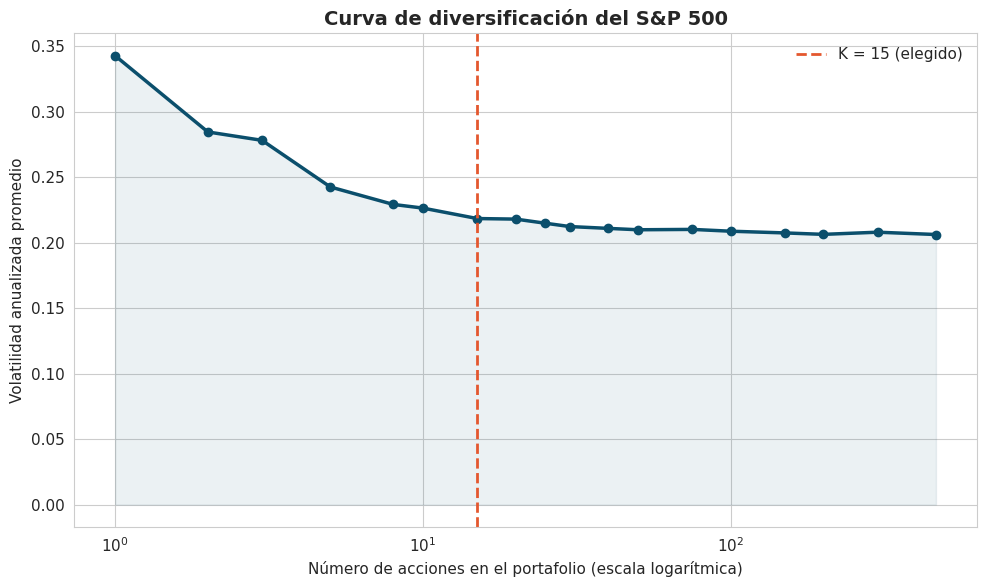

Volatilidad con  1 acción:  0.343
Volatilidad con 15 acciones: 0.218
Volatilidad con 464 acciones: 0.206

Con solo 15 acciones ya se captura el 91% del beneficio total de diversificación disponible.


In [5]:
simple_rets_all = prices_clean.pct_change().dropna()
np.random.seed(42)
Ns = [1, 2, 3, 5, 8, 10, 15, 20, 25, 30, 40, 50, 75, 100, 150, 200, 300, 464]

vol_por_N = {}
for N in Ns:
    vols = []
    for _ in range(30):
        muestra = np.random.choice(simple_rets_all.columns, size=N, replace=False)
        port = simple_rets_all[muestra].mean(axis=1)
        vols.append(port.std() * np.sqrt(TRADING_DAYS))
    vol_por_N[N] = np.mean(vols)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(list(vol_por_N.keys()), list(vol_por_N.values()), marker='o', color=NAVY, linewidth=2.5, markersize=6)
ax.axvline(15, color=ORANGE, linestyle='--', linewidth=2, label='K = 15 (elegido)')
ax.fill_between(list(vol_por_N.keys()), list(vol_por_N.values()), alpha=0.08, color=NAVY)
ax.set_xscale('log')
ax.set_xlabel('Número de acciones en el portafolio (escala logarítmica)')
ax.set_ylabel('Volatilidad anualizada promedio')
ax.set_title('Curva de diversificación del S&P 500')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print(f"Volatilidad con  1 acción:  {vol_por_N[1]:.3f}")
print(f"Volatilidad con 15 acciones: {vol_por_N[15]:.3f}")
print(f"Volatilidad con 464 acciones: {vol_por_N[464]:.3f}")
print(f"\nCon solo 15 acciones ya se captura el {(1 - (vol_por_N[15]-vol_por_N[464])/(vol_por_N[1]-vol_por_N[464]))*100:.0f}% del beneficio total de diversificación disponible.")

**Conclusión:** la caída de riesgo es empinada hasta ~15-20 acciones y luego se aplana — agregar cientos de acciones más solo reduce el riesgo de forma marginal. Por eso trabajamos con un universo reducido de **15 acciones bien elegidas**, no con las ~500 completas.

## 4. Ingeniería de características

Para poder comparar empresas y agruparlas, se calcula un "perfil financiero" de cada una, usando **retornos logarítmicos** (más apropiados para describir el comportamiento estadístico de un activo individual que los retornos simples):

| Variable | Qué mide |
|---|---|
| Retorno anualizado | Rentabilidad promedio del periodo |
| Volatilidad anualizada | Riesgo total (qué tan "movida" es la acción) |
| Beta | Sensibilidad al mercado (S&P 500) |
| Sharpe Ratio | Retorno obtenido por unidad de riesgo asumido |
| Precio / Valor en Libros (P/B) | Indicador de valoración fundamental |

**Nota de diseño importante:** el Sharpe Ratio se calcula, pero **no se usa como variable para agrupar** — se reserva como criterio de selección posterior (Sección 6). Usarlo en ambos pasos sería aplicar la misma información dos veces.

In [7]:
archivo.seek(0)
info = pd.read_excel(archivo, sheet_name='Worksheet').set_index('Ticker')
book_value = pd.to_numeric(info['valor en libros '], errors='coerce')
price_now = pd.to_numeric(info['Price'], errors='coerce')
pb_ratio = price_now / book_value

from scipy.stats import skew

log_rets = np.log(prices_clean / prices_clean.shift(1)).dropna()
log_idx_rets = np.log(idx / idx.shift(1)).dropna()
common = log_rets.index.intersection(log_idx_rets.index)
log_rets = log_rets.loc[common]
log_idx_rets = log_idx_rets.loc[common]

ann_ret = np.exp(log_rets.mean() * TRADING_DAYS) - 1
ann_vol = log_rets.std() * np.sqrt(TRADING_DAYS)
beta = log_rets.apply(lambda c: c.cov(log_idx_rets) / log_idx_rets.var())
sharpe_feat = (ann_ret - RF_ANUAL) / ann_vol

features = pd.DataFrame({'Retorno': ann_ret, 'Volatilidad': ann_vol, 'Beta': beta, 'Sharpe': sharpe_feat})
features['Name'] = info['Name'].reindex(features.index)
features['PB'] = pb_ratio.reindex(features.index)
features['PB'] = features['PB'].fillna(features['PB'].median())     # imputar con la mediana si falta el dato
features['PB_log'] = np.log(features['PB'].clip(lower=0.1))         # log para reducir la fuerte asimetria del P/B

cols_cluster = ['Retorno', 'Volatilidad', 'Beta', 'PB_log']          # variables usadas para AGRUPAR

features[cols_cluster + ['Sharpe']].describe().round(3)

,Retorno,Volatilidad,Beta,PB_log,Sharpe
count,464.000,464.000,464.000,464.000,464.000
mean,0.100,0.354,0.979,3.471,0.181
std,0.126,0.099,0.326,1.032,0.311
min,-0.174,0.194,0.149,-2.303,-0.551
25%,0.027,0.287,0.736,2.934,-0.008
50%,0.082,0.331,0.954,3.599,0.155
75%,0.150,0.401,1.168,4.093,0.348
max,0.699,1.036,2.369,7.166,1.321


## 5. K-Medoids (PAM) — segmentación del mercado

**¿Por qué K-Medoids y no K-Means?** El centroide de K-Means es un promedio matemático que casi nunca corresponde a una empresa real. El medoide de K-Medoids **sí es una observación real** — la empresa del grupo cuya suma de distancias a las demás es mínima. Como `scikit-learn` no incluye K-Medoids de forma nativa, se implementa el algoritmo **PAM (Partitioning Around Medoids)** en su versión alternada.

In [8]:
def kmedoids_pam(X, k, random_state=42, max_iter=100):
    """
    K-Medoids mediante el algoritmo PAM (version alternada).
    Distancia: Euclidiana (caso particular de Minkowski con p=2).
    """
    rng = np.random.default_rng(random_state)
    n = X.shape[0]
    D = cdist(X, X, metric='euclidean')

    # Inicializacion tipo k-means++: medoides iniciales alejados entre si
    medoid_idx = [rng.integers(n)]
    for _ in range(1, k):
        dist_to_closest = D[:, medoid_idx].min(axis=1)
        probs = dist_to_closest ** 2
        probs /= probs.sum()
        medoid_idx.append(rng.choice(n, p=probs))
    medoid_idx = np.array(medoid_idx)

    # Iterar: asignar cada punto al medoide mas cercano, luego actualizar medoides
    for _ in range(max_iter):
        labels = np.argmin(D[:, medoid_idx], axis=1)
        new_medoid_idx = medoid_idx.copy()
        for c in range(k):
            members = np.where(labels == c)[0]
            if len(members) == 0:
                continue
            costs = D[np.ix_(members, members)].sum(axis=1)
            new_medoid_idx[c] = members[np.argmin(costs)]
        if np.array_equal(new_medoid_idx, medoid_idx):
            break
        medoid_idx = new_medoid_idx

    labels = np.argmin(D[:, medoid_idx], axis=1)
    return medoid_idx, labels

K = 15
X = StandardScaler().fit_transform(features[cols_cluster])   # estandarizar: las 4 variables tienen escalas muy distintas
medoid_idx, labels = kmedoids_pam(X, K)
features['cluster'] = labels

print(f"Segmentación completa: el mercado se dividió en {K} grupos.")
print("Tamaño de cada grupo:", features['cluster'].value_counts().sort_index().tolist())

Segmentación completa: el mercado se dividió en 15 grupos.
Tamaño de cada grupo: [84, 29, 28, 8, 29, 45, 23, 31, 55, 16, 9, 22, 1, 54, 30]


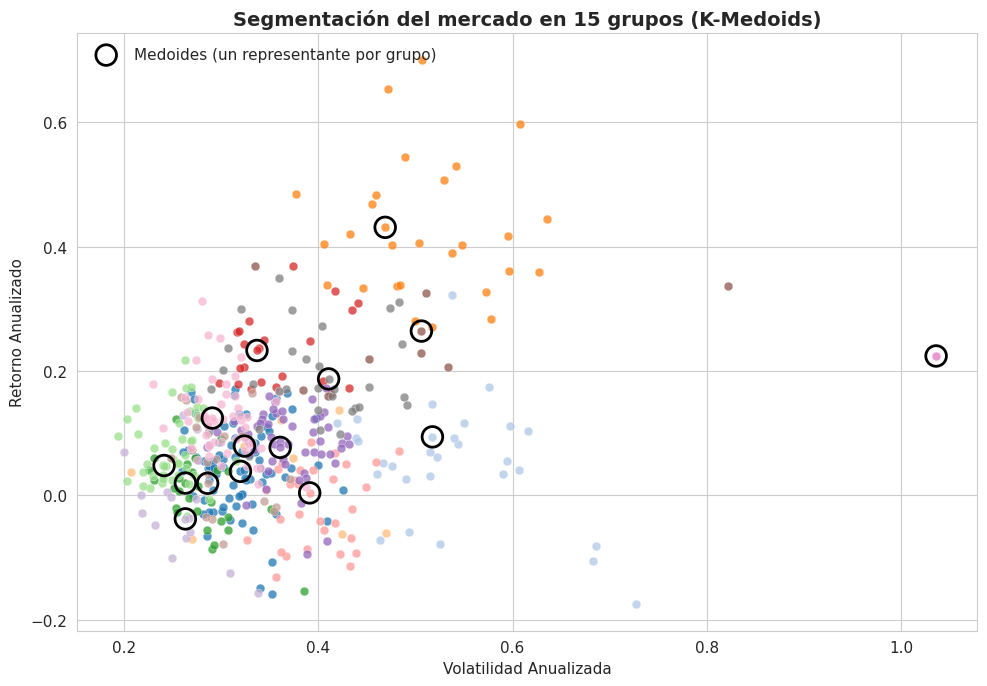

In [9]:
fig, ax = plt.subplots(figsize=(10, 7))
colores_clusters = sns.color_palette('tab20', K)
for c in range(K):
    sub = features[features['cluster'] == c]
    ax.scatter(sub['Volatilidad'], sub['Retorno'], color=colores_clusters[c], s=40, alpha=0.75, edgecolor='white', linewidth=0.3)

medoides_tickers = features.index[medoid_idx]
ax.scatter(features.loc[medoides_tickers, 'Volatilidad'], features.loc[medoides_tickers, 'Retorno'],
           facecolors='none', edgecolors='black', s=220, linewidths=2, label='Medoides (un representante por grupo)')

ax.set_xlabel('Volatilidad Anualizada')
ax.set_ylabel('Retorno Anualizado')
ax.set_title(f'Segmentación del mercado en {K} grupos (K-Medoids)')
ax.legend(frameon=False, loc='upper left')
plt.tight_layout()
plt.show()

## 6. Smart Selection — elegir la mejor acción de cada grupo

En vez de tomar el medoide (la acción más "típica" de cada grupo), se elige la acción con **mejor Sharpe Ratio dentro de ese mismo grupo**. La lógica: se sigue teniendo representación de los 15 "tipos" de comportamiento del mercado (porque la acción elegida sale del mismo grupo que el medoide), pero se elige la mejor versión de cada tipo, no la más promedio.

In [10]:
smart_selection = [features[features['cluster'] == c]['Sharpe'].idxmax() for c in range(K)]
medoides_puros = features.index[medoid_idx].tolist()

tabla_comparacion = pd.DataFrame({
    'Medoide (típico)': [t.split()[0] for t in medoides_puros],
    'Sharpe medoide': features.loc[medoides_puros, 'Sharpe'].values,
    'Smart Selection (mejor)': [t.split()[0] for t in smart_selection],
    'Sharpe smart': features.loc[smart_selection, 'Sharpe'].values,
})
tabla_comparacion.round(3)

,Medoide (típico),Sharpe medoide,Smart Selection (mejor),Sharpe smart
0,GPC,0.027,MSI,0.509
1,GNRC,0.124,MPWR,0.542
2,FLEX,0.855,NVDA,1.321
3,MTD,0.152,LYV,0.254
4,AWK,-0.039,DGX,0.364
5,SO,0.075,COR,0.711
6,MS,0.603,EME,0.903
7,BBY,-0.066,RF,0.144
8,WFC,0.131,AMZN,0.373
9,PFE,-0.257,GILD,0.382


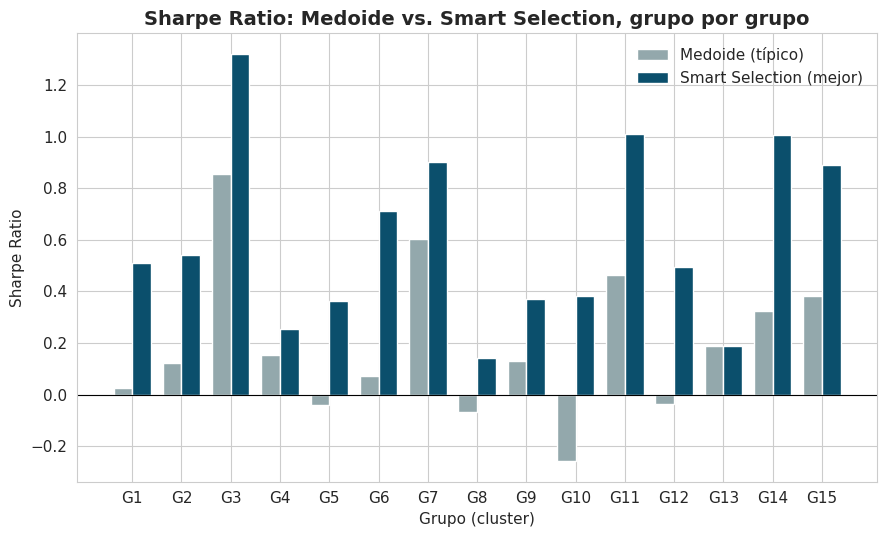

Sharpe promedio -> Medoide: 0.195  |  Smart Selection: 0.606
Volatilidad promedio -> Medoide: 0.401  |  Smart Selection: 0.393


In [11]:
fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(K)
width = 0.38
ax.bar(x - width/2, features.loc[medoides_puros, 'Sharpe'].values, width, label='Medoide (típico)', color=GRAY)
ax.bar(x + width/2, features.loc[smart_selection, 'Sharpe'].values, width, label='Smart Selection (mejor)', color=NAVY)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels([f'G{c+1}' for c in range(K)])
ax.set_xlabel('Grupo (cluster)')
ax.set_ylabel('Sharpe Ratio')
ax.set_title('Sharpe Ratio: Medoide vs. Smart Selection, grupo por grupo')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print(f"Sharpe promedio -> Medoide: {features.loc[medoides_puros,'Sharpe'].mean():.3f}  |  Smart Selection: {features.loc[smart_selection,'Sharpe'].mean():.3f}")
print(f"Volatilidad promedio -> Medoide: {features.loc[medoides_puros,'Volatilidad'].mean():.3f}  |  Smart Selection: {features.loc[smart_selection,'Volatilidad'].mean():.3f}")

**Lectura:** Smart Selection gana en Sharpe en la gran mayoría de los grupos, con una volatilidad promedio muy similar a la del medoide — se obtiene mejor retorno ajustado por riesgo sin pagar más riesgo por ello.

## 7. Matriz de correlación y red de diversificación

Antes de calcular los pesos del portafolio, conviene **verificar visualmente si las 15 acciones elegidas realmente están diversificadas** entre sí — el proceso de selección optimizó por perfil de riesgo-retorno, no directamente por baja correlación, así que vale la pena comprobarlo por separado.

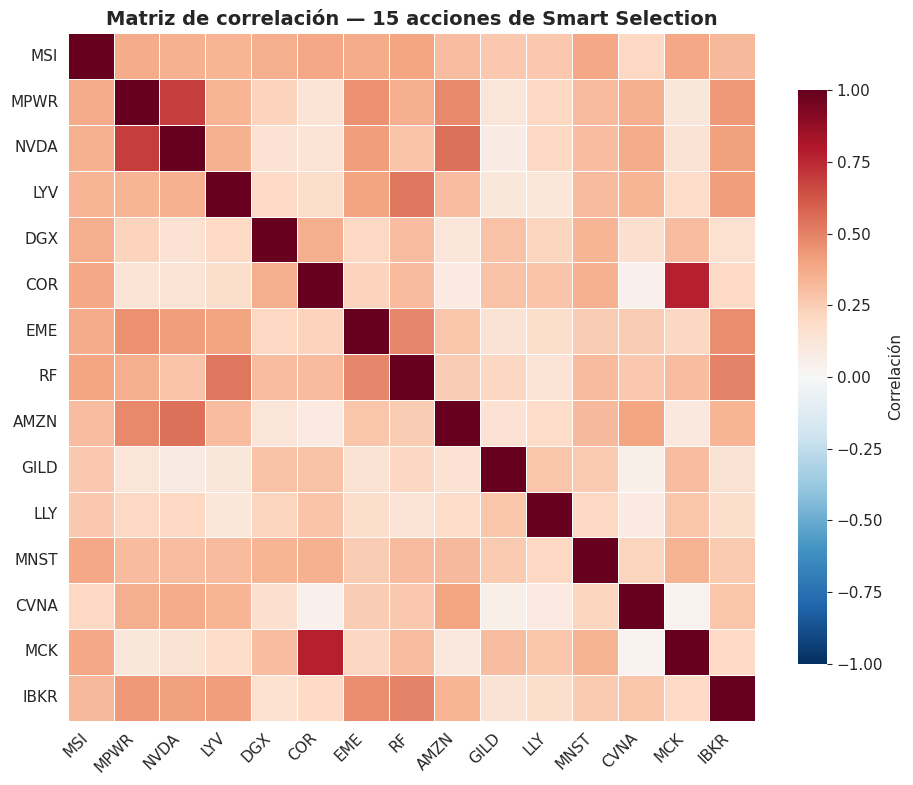

Correlación promedio entre las 15 acciones: 0.281
Correlación máxima entre un par: 0.776   |   mínima: 0.047


In [12]:
simple_rets_seleccion = prices_clean[smart_selection].pct_change().dropna()
corr_seleccion = simple_rets_seleccion.corr()

fig, ax = plt.subplots(figsize=(9.5, 8))
sns.heatmap(corr_seleccion, cmap='RdBu_r', center=0, vmin=-1, vmax=1, square=True,
            xticklabels=[t.split()[0] for t in corr_seleccion.index],
            yticklabels=[t.split()[0] for t in corr_seleccion.index],
            cbar_kws={'label': 'Correlación', 'shrink': 0.8}, linewidths=0.5, linecolor='white', ax=ax)
ax.set_title('Matriz de correlación — 15 acciones de Smart Selection')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

vals = corr_seleccion.values[np.triu_indices(len(corr_seleccion), 1)]
print(f"Correlación promedio entre las 15 acciones: {vals.mean():.3f}")
print(f"Correlación máxima entre un par: {vals.max():.3f}   |   mínima: {vals.min():.3f}")

### Red de diversificación

La misma información de la matriz de correlación, ahora como un **grafo**: cada nodo es una acción, y se traza una línea entre dos acciones si su correlación supera un umbral. Si el portafolio está bien diversificado, la red se ve dispersa, con pocas conexiones fuertes. Si estuviera concentrado, veríamos un grupo de nodos muy densamente conectados entre sí.

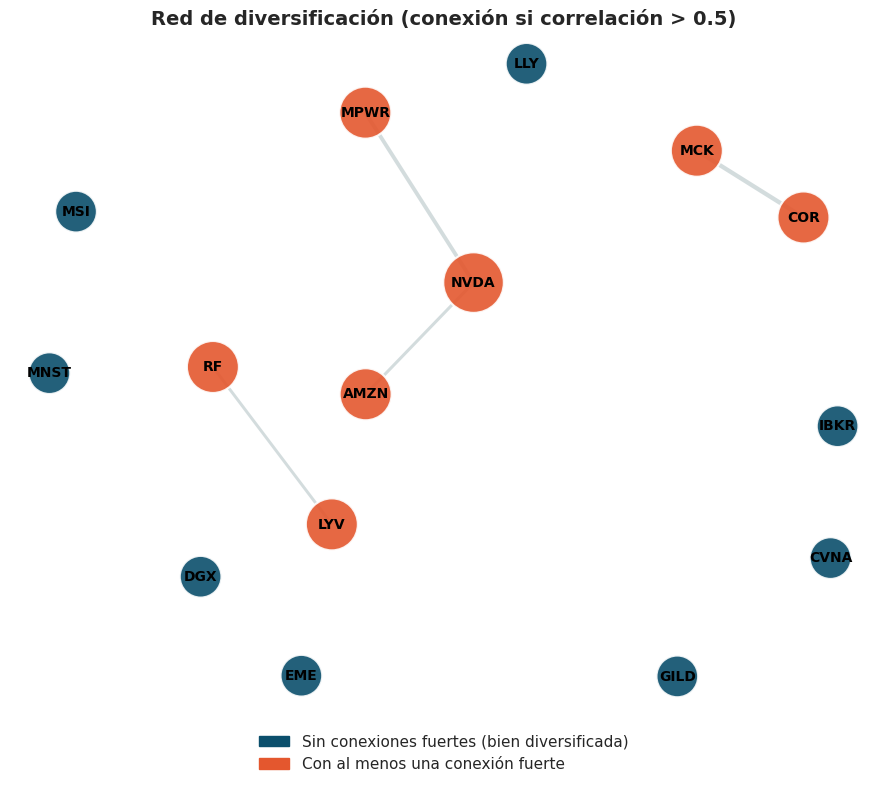

Acciones sin ninguna conexión fuerte (grado 0): 8 de 15
Conexiones totales por encima del umbral: 4


In [13]:
UMBRAL_RED = 0.5   # se traza conexion solo si la correlacion supera este valor

G = nx.Graph()
G.add_nodes_from([t.split()[0] for t in corr_seleccion.index])
for i in range(len(corr_seleccion)):
    for j in range(i + 1, len(corr_seleccion)):
        corr_ij = corr_seleccion.iloc[i, j]
        if corr_ij > UMBRAL_RED:
            G.add_edge(corr_seleccion.index[i].split()[0], corr_seleccion.index[j].split()[0], weight=corr_ij)

fig, ax = plt.subplots(figsize=(9, 8))
pos = nx.spring_layout(G, seed=7, k=0.9)

grados = dict(G.degree())
node_sizes = [900 + 500 * grados[n] for n in G.nodes()]
node_colors = [ORANGE if grados[n] > 0 else NAVY for n in G.nodes()]

edge_weights = [G[u][v]['weight'] * 4 for u, v in G.edges()]
nx.draw_networkx_edges(G, pos, width=edge_weights, alpha=0.4, edge_color=GRAY, ax=ax)
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, alpha=0.9, ax=ax, edgecolors='white', linewidths=1.5)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold', ax=ax)

ax.set_title(f'Red de diversificación (conexión si correlación > {UMBRAL_RED})')
ax.axis('off')

leyenda = [mpatches.Patch(color=NAVY, label='Sin conexiones fuertes (bien diversificada)'),
           mpatches.Patch(color=ORANGE, label='Con al menos una conexión fuerte')]
ax.legend(handles=leyenda, loc='upper center', bbox_to_anchor=(0.5, -0.02), ncol=1, frameon=False)
plt.tight_layout()
plt.show()

n_aisladas = sum(1 for n in G.nodes() if grados[n] == 0)
print(f"Acciones sin ninguna conexión fuerte (grado 0): {n_aisladas} de {len(G.nodes())}")
print(f"Conexiones totales por encima del umbral: {G.number_of_edges()}")

**Cómo interpretar:** si la mayoría de los nodos aparecen en azul (sin conexiones fuertes) y hay pocas líneas en el grafo, la selección logró una diversificación real — las 15 acciones no dependen unas de otras de forma marcada. Si aparecieran muchos nodos naranjas muy conectados entre sí, sería una señal de alerta: la selección tendría redundancia oculta que el perfil de riesgo-retorno por sí solo no detecta.

## 8. HRP — Ponderación Jerárquica del Riesgo (Hierarchical Risk Parity)

HRP reparte el capital en 3 fases, sin necesitar invertir la matriz de covarianza completa (a diferencia de Markowitz, que sí la necesita y es numéricamente inestable cuando hay muchos activos correlacionados):

**Fase 1 — Agrupamiento jerárquico:** convertir la correlación en una distancia ($d_{ij} = \sqrt{0.5(1-\rho_{ij})}$) y construir un árbol (dendrograma) que una a los activos más parecidos primero.

**Fase 2 — Cuasi-diagonalización:** reordenar la matriz de covarianza según el orden del árbol, agrupando visualmente los activos parecidos en bloques.

**Fase 3 — Bisección recursiva:** repartir el capital de arriba hacia abajo, dividiendo el árbol en dos mitades en cada paso, y asignando más peso a la mitad de **menor varianza**.

**Nota de diseño:** se usa el método de enlace `ward` en vez del `single` del paper original de HRP — `single` tiende a generar cadenas de fusión desbalanceadas; `ward` agrupa minimizando la varianza interna de cada grupo, lo que da una estructura más equilibrada para la bisección recursiva posterior.

In [14]:
def get_quasi_diag(link):
    """Fase 2: devuelve el orden de los activos segun las hojas del dendrograma."""
    link = link.astype(int)
    sort_ix = pd.Series([link[-1, 0], link[-1, 1]])
    num_items = link[-1, 3]
    while sort_ix.max() >= num_items:
        sort_ix.index = range(0, sort_ix.shape[0] * 2, 2)
        df0 = sort_ix[sort_ix >= num_items]
        i = df0.index
        j = df0.values - num_items
        sort_ix[i] = link[j, 0]
        df1 = pd.Series(link[j, 1], index=i + 1)
        sort_ix = pd.concat([sort_ix, df1]).sort_index()
        sort_ix.index = range(sort_ix.shape[0])
    return sort_ix.tolist()

def get_cluster_var(cov, items):
    """Varianza de un sub-grupo usando pesos de minima varianza (Inverse Variance Portfolio)."""
    cov_slice = cov.loc[items, items]
    ivp = 1. / np.diag(cov_slice)
    ivp /= ivp.sum()
    return np.dot(ivp, np.dot(cov_slice, ivp))

def get_rec_bipart(cov, sort_ix):
    """Fase 3: biseccion recursiva de arriba hacia abajo."""
    w = pd.Series(1.0, index=sort_ix)
    c_items = [sort_ix]
    while len(c_items) > 0:
        c_items = [i[j:k] for i in c_items for j, k in
                   ((0, len(i) // 2), (len(i) // 2, len(i))) if len(i) > 1]
        for i in range(0, len(c_items), 2):
            c0 = c_items[i]
            c1 = c_items[i + 1]
            var0 = get_cluster_var(cov, c0)
            var1 = get_cluster_var(cov, c1)
            alpha = 1 - var0 / (var0 + var1)
            w[c0] *= alpha
            w[c1] *= 1 - alpha
    return w

def hrp_weights(returns_train, method='ward'):
    """Pipeline completo de HRP: las 3 fases encadenadas."""
    corr = returns_train.corr()
    cov = returns_train.cov()
    dist = np.sqrt(0.5 * (1 - corr))
    condensed = squareform(dist.values, checks=False)
    link = linkage(condensed, method=method)
    sort_ix_num = get_quasi_diag(link)
    sort_ix_labels = corr.index[sort_ix_num].tolist()
    w = get_rec_bipart(cov, sort_ix_labels).sort_index()
    return w

print("Funciones de HRP definidas (3 fases, linkage='ward').")

Funciones de HRP definidas (3 fases, linkage='ward').


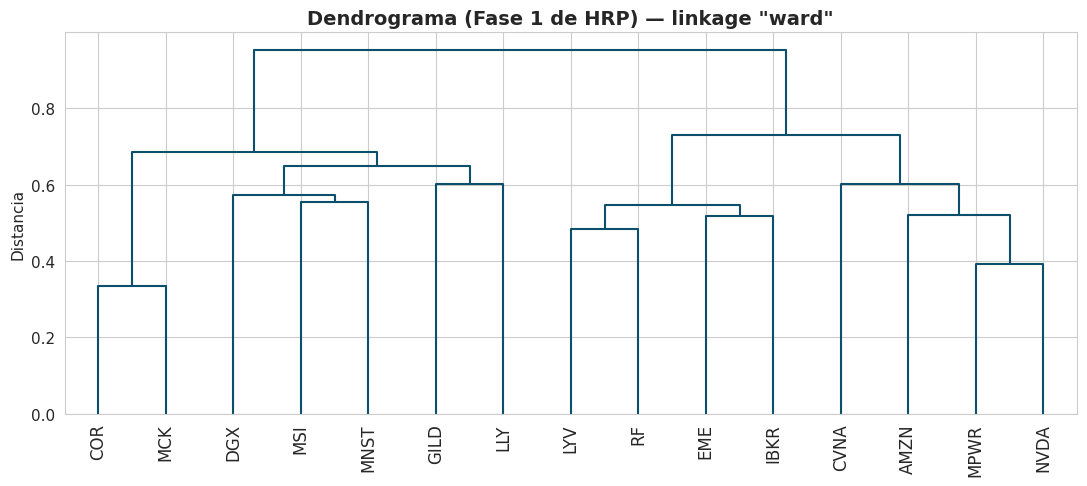

In [15]:
# Dendrograma ilustrativo de las 15 acciones de Smart Selection (todo el periodo, solo para visualizar la Fase 1)
dist_ilustrativo = np.sqrt(0.5 * (1 - corr_seleccion))
link_ilustrativo = linkage(squareform(dist_ilustrativo.values, checks=False), method='ward')

fig, ax = plt.subplots(figsize=(11, 5))
dendrogram(link_ilustrativo, labels=[t.split()[0] for t in corr_seleccion.index],
           ax=ax, leaf_rotation=90, color_threshold=0, above_threshold_color=NAVY)
ax.set_title('Dendrograma (Fase 1 de HRP) — linkage "ward"')
ax.set_ylabel('Distancia')
plt.tight_layout()
plt.show()

## 8.1 Pesos finales asignados por HRP

Antes de pasar a la validación con ventanas móviles, es importante ver **qué pesos concretos le asignó HRP a cada una de las 15 acciones** — esto es lo que responde la pregunta "¿en qué se invierte realmente, y cuánto en cada una?". Se calcula aquí de forma ilustrativa usando **todo el periodo 2020-2026** (en el backtesting de la Sección 9 estos pesos se recalculan por separado en cada ventana, usando solo datos de entrenamiento).

In [16]:
w_hrp_ilustrativo = hrp_weights(simple_rets_seleccion, method='ward')

tabla_pesos = pd.DataFrame({
    'Nombre': features.loc[w_hrp_ilustrativo.index, 'Name'],
    'Peso HRP (%)': (w_hrp_ilustrativo.values * 100).round(2),
    'Volatilidad': features.loc[w_hrp_ilustrativo.index, 'Volatilidad'].round(3).values,
    'Beta': features.loc[w_hrp_ilustrativo.index, 'Beta'].round(2).values,
}).sort_values('Peso HRP (%)', ascending=False)

print(f"Suma de los pesos: {w_hrp_ilustrativo.sum():.4f}  (debe ser 1.0)")
print(f"Peso equal-weight de referencia (1/{K}): {1/K:.4f}")
tabla_pesos

Suma de los pesos: 1.0000  (debe ser 1.0)
Peso equal-weight de referencia (1/15): 0.0667


,Nombre,Peso HRP (%),Volatilidad,Beta
COR UN Equity,Cencora Inc,12.70,0.263,0.53
GILD UW Equity,Gilead Sciences Inc,11.98,0.261,0.45
MNST UW Equity,Monster Beverage Corp,11.17,0.259,0.73
MSI UN Equity,Motorola Solutions Inc,10.50,0.269,0.83
DGX UN Equity,Quest Diagnostics Inc,10.32,0.254,0.51
MCK UN Equity,McKesson Corp,8.37,0.280,0.56
LLY UN Equity,Eli Lilly & Co,7.22,0.335,0.63
AMZN UW Equity,Amazon.com Inc,6.06,0.350,1.13
IBKR UW Equity,Interactive Brokers Group Inc,4.93,0.360,1.07
EME UN Equity,EMCOR Group Inc,4.63,0.375,1.11


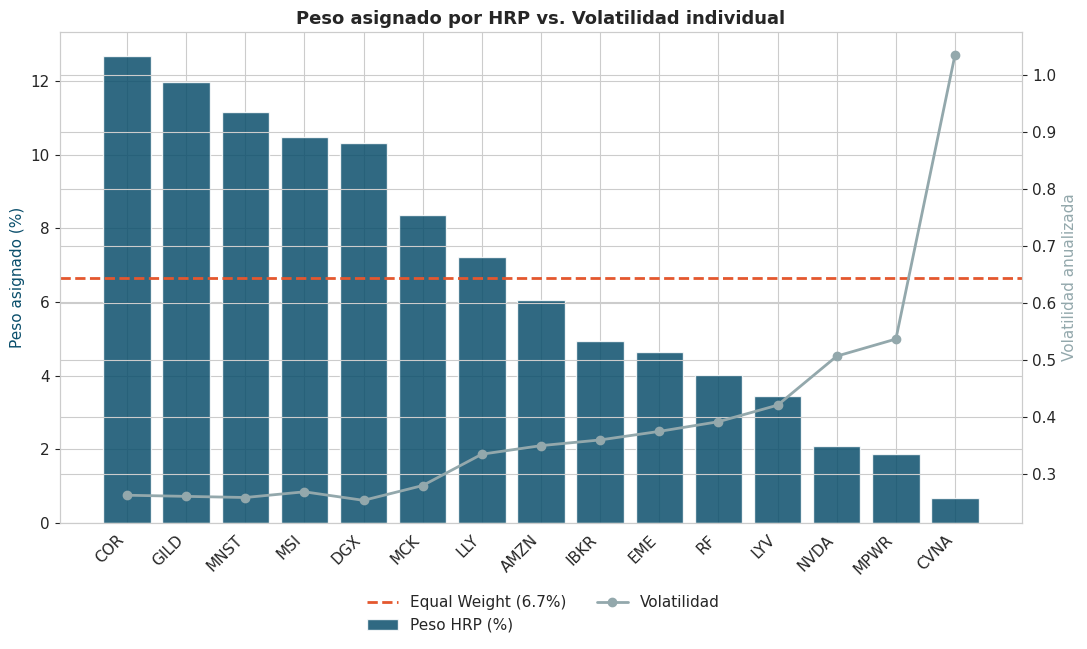

Correlación entre peso asignado y volatilidad individual: -0.753


In [17]:
fig, ax1 = plt.subplots(figsize=(11, 6))
orden = tabla_pesos.index
tickers_cortos = [t.split()[0] for t in orden]

ax1.bar(tickers_cortos, tabla_pesos['Peso HRP (%)'], color=NAVY, alpha=0.85, label='Peso HRP (%)')
ax1.axhline(100/K, color=ORANGE, linestyle='--', linewidth=2, label=f'Equal Weight ({100/K:.1f}%)')
ax1.set_ylabel('Peso asignado (%)', color=NAVY)
ax1.set_xlabel('')
plt.xticks(rotation=45, ha='right')

ax2 = ax1.twinx()
ax2.plot(tickers_cortos, tabla_pesos['Volatilidad'], color=GRAY, marker='o', linewidth=2, label='Volatilidad')
ax2.set_ylabel('Volatilidad anualizada', color=GRAY)

ax1.set_title('Peso asignado por HRP vs. Volatilidad individual', fontsize=13, fontweight='bold')
fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=2, frameon=False)
plt.tight_layout()
plt.show()

corr_peso_vol = tabla_pesos['Peso HRP (%)'].corr(tabla_pesos['Volatilidad'])
print(f"Correlación entre peso asignado y volatilidad individual: {corr_peso_vol:.3f}")

**Cómo interpretar este resultado:** hay una relación claramente **negativa** entre el peso que HRP le asigna a una acción y su volatilidad individual — las acciones más "tranquilas" (menor volatilidad) reciben más capital, y las más volátiles reciben menos, sin importar qué retorno histórico hayan tenido.

Esto **no es un descuido del algoritmo, es su diseño explícito**: HRP nunca mira el retorno esperado, solo reparte el riesgo. Por eso una acción como NVIDIA o Carvana, con retornos históricos altos pero volatilidad muy alta, termina con un peso pequeño — mientras que empresas más estables (aunque con retornos más modestos) concentran más del capital. Este mecanismo es exactamente el que explica por qué HRP salió con **menor volatilidad total que Equal Weight** en el backtesting de la Sección 10.

## 9. Backtesting con Ventanas Móviles

Con los ~6.7 años de datos disponibles (2020-2026), se definen **3 ventanas móviles** de 3 años de entrenamiento + 2 años de prueba, desplazadas 1 año cada vez:

| Ventana | Entrenamiento | Prueba |
|---|---|---|
| 1 | 2020 – 2022 | 2023 – 2024 |
| 2 | 2021 – 2023 | 2024 – 2025 |
| 3 | 2022 – 2024 | 2025 – 2026 (parcial) |

**En cada ventana se repite todo el proceso desde cero, usando solo datos de entrenamiento** (segmentación con K-Medoids, Smart Selection, pesos de HRP) — y se evalúa exclusivamente en el periodo de prueba siguiente, que el cálculo nunca vio. Esto evita *data leakage* y es lo que realmente significa "validación fuera de muestra".

In [18]:
def portfolio_metrics(port_rets, bench_rets, rf_annual=RF_ANUAL):
    ann_ret_ = (1 + port_rets).prod() ** (TRADING_DAYS / len(port_rets)) - 1
    ann_vol_ = port_rets.std() * np.sqrt(TRADING_DAYS)
    sharpe_ = (ann_ret_ - rf_annual) / ann_vol_
    cum_ = (1 + port_rets).cumprod()
    max_dd_ = (cum_ / cum_.cummax() - 1).min()
    excess_p = port_rets - rf_daily
    excess_b = bench_rets - rf_daily
    beta_p, alpha_daily, r_val, p_val, se = linregress(excess_b, excess_p)
    alpha_anual = alpha_daily * TRADING_DAYS
    treynor_ = (ann_ret_ - rf_annual) / beta_p if beta_p != 0 else np.nan
    return dict(ret=ann_ret_, vol=ann_vol_, sharpe=sharpe_, dd=max_dd_, beta=beta_p,
                alpha=alpha_anual, pval=p_val, treynor=treynor_)

ventanas = [
    ('2020-01-01', '2022-12-31', '2023-01-01', '2024-12-31'),
    ('2021-01-01', '2023-12-31', '2024-01-01', '2025-12-31'),
    ('2022-01-01', '2024-12-31', '2025-01-01', '2026-09-07'),
]

resultados_todas = []
cumulativos_ventana = {}
selecciones_por_ventana = {}

for i, (tr_s, tr_e, te_s, te_e) in enumerate(ventanas):
    train_prices = prices_clean.loc[tr_s:tr_e]
    test_prices = prices_clean.loc[te_s:te_e]
    train_idx_p = idx.loc[tr_s:tr_e]
    test_idx_p = idx.loc[te_s:te_e]

    miss_train = train_prices.isna().mean()
    miss_test = test_prices.isna().mean()
    validos = [t for t in miss_train[miss_train == 0].index if miss_test.get(t, 1) == 0]
    train_prices_v = train_prices[validos]
    test_prices_v = test_prices[validos]

    log_rets_train = np.log(train_prices_v / train_prices_v.shift(1)).dropna()
    log_idx_train = np.log(train_idx_p / train_idx_p.shift(1)).dropna()
    common_tr = log_rets_train.index.intersection(log_idx_train.index)
    log_rets_train = log_rets_train.loc[common_tr]
    log_idx_train = log_idx_train.loc[common_tr]

    ann_ret_v = np.exp(log_rets_train.mean() * TRADING_DAYS) - 1
    ann_vol_v = log_rets_train.std() * np.sqrt(TRADING_DAYS)
    beta_v = log_rets_train.apply(lambda c: c.cov(log_idx_train) / log_idx_train.var())
    sharpe_v = (ann_ret_v - RF_ANUAL) / ann_vol_v

    feats_v = pd.DataFrame({'Retorno': ann_ret_v, 'Volatilidad': ann_vol_v, 'Beta': beta_v, 'Sharpe': sharpe_v})
    feats_v['PB'] = pb_ratio.reindex(feats_v.index)
    feats_v['PB'] = feats_v['PB'].fillna(feats_v['PB'].median())
    feats_v['PB_log'] = np.log(feats_v['PB'].clip(lower=0.1))

    X_v = StandardScaler().fit_transform(feats_v[cols_cluster])
    medoid_idx_v, labels_v = kmedoids_pam(X_v, K)
    feats_v['cluster'] = labels_v
    smart_v = [feats_v[feats_v['cluster'] == c]['Sharpe'].idxmax() for c in range(K)]
    selecciones_por_ventana[i + 1] = smart_v

    simple_rets_train = train_prices_v.pct_change().dropna()
    simple_rets_test = test_prices_v.pct_change().dropna()
    simple_idx_test = test_idx_p.pct_change().dropna()
    common_test = simple_rets_test.index.intersection(simple_idx_test.index)
    simple_idx_test_v = simple_idx_test.loc[common_test]

    w_hrp = hrp_weights(simple_rets_train[smart_v], method='ward')
    rets_test_sel = simple_rets_test[smart_v].loc[common_test]
    port = (rets_test_sel[w_hrp.index] * w_hrp).sum(axis=1)

    m = portfolio_metrics(port, simple_idx_test_v)
    m['ventana'] = i + 1
    m['metodo'] = 'Smart Selection + HRP'
    resultados_todas.append(m)

    m_bench = portfolio_metrics(simple_idx_test_v, simple_idx_test_v)
    m_bench['ventana'] = i + 1
    m_bench['metodo'] = 'S&P 500'
    resultados_todas.append(m_bench)

    cumulativos_ventana[i + 1] = {
        'Smart Selection + HRP': (1 + port).cumprod(),
        'S&P 500': (1 + simple_idx_test_v).cumprod()
    }

    print(f"Ventana {i+1}: entrenado {tr_s} a {tr_e}, evaluado {te_s} a {te_e}  -> completado")

df_resultados = pd.DataFrame(resultados_todas)
print("\nBacktesting completo.")

Ventana 1: entrenado 2020-01-01 a 2022-12-31, evaluado 2023-01-01 a 2024-12-31  -> completado
Ventana 2: entrenado 2021-01-01 a 2023-12-31, evaluado 2024-01-01 a 2025-12-31  -> completado
Ventana 3: entrenado 2022-01-01 a 2024-12-31, evaluado 2025-01-01 a 2026-09-07  -> completado

Backtesting completo.


## 10. Resultados y validación

In [19]:
tabla_por_ventana = df_resultados.pivot(index='ventana', columns='metodo', values=['ret', 'sharpe', 'treynor', 'alpha'])
tabla_por_ventana.round(4)

ret                        sharpe                       treynor  \
metodo  S&P 500 Smart Selection + HRP S&P 500 Smart Selection + HRP S&P 500   
ventana                                                                       
1        0.2291                0.0936  1.5771                0.4797  0.1991   
2        0.1905                0.2912  1.0252                1.5186  0.1605   
3        0.1693                0.2473  0.8479                1.4519  0.1393   

                                alpha                        
metodo  Smart Selection + HRP S&P 500 Smart Selection + HRP  
ventana                                                      
1                      0.0771     0.0               -0.0838  
2                      0.2868     0.0                0.0978  
3                      0.3225     0.0                0.1080

In [ ]:
resumen = df_resultados.groupby('metodo')[['ret', 'vol', 'sharpe', 'treynor', 'alpha']].agg(['mean', 'std']).round(4)
print("Promedio ± desviación estándar a través de las 3 ventanas:")
resumen

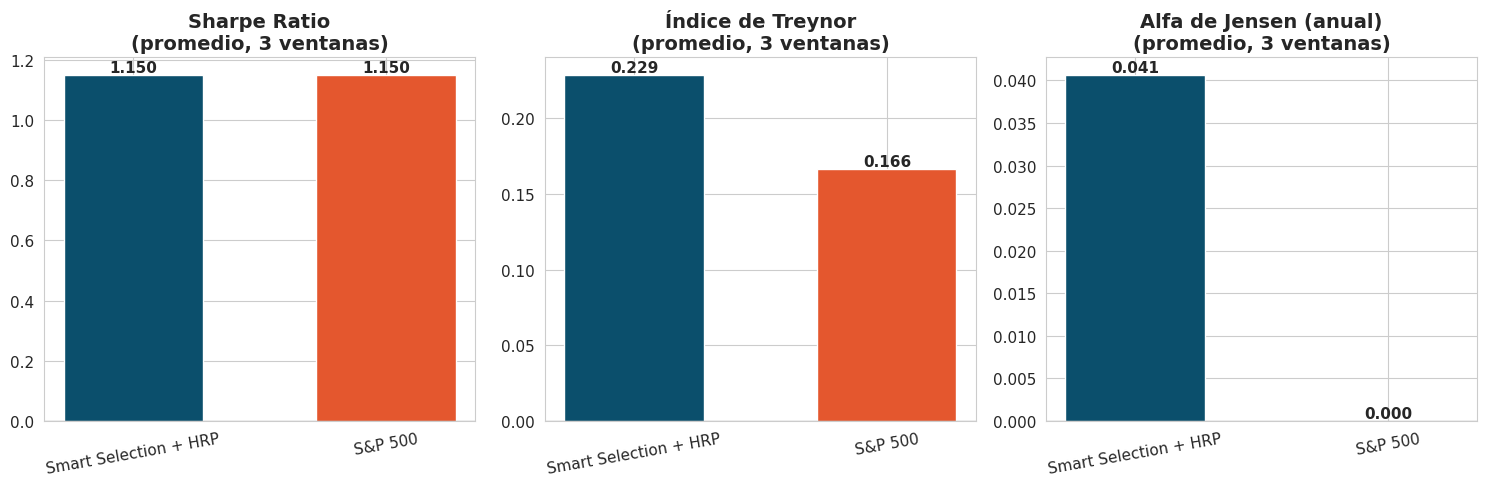

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metodos = ['Smart Selection + HRP', 'S&P 500']
colores = [NAVY, ORANGE]

for ax, metrica, titulo in zip(axes, ['sharpe', 'treynor', 'alpha'], ['Sharpe Ratio', 'Índice de Treynor', 'Alfa de Jensen (anual)']):
    valores = [df_resultados[df_resultados['metodo'] == m][metrica].mean() for m in metodos]
    barras = ax.bar(metodos, valores, color=colores, width=0.55)
    for barra, val in zip(barras, valores):
        ax.text(barra.get_x() + barra.get_width()/2, val, f'{val:.3f}', ha='center',
                va='bottom' if val >= 0 else 'top', fontsize=11, fontweight='bold')
    ax.set_title(f'{titulo}\n(promedio, 3 ventanas)')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.tick_params(axis='x', rotation=10)

plt.tight_layout()
plt.show()

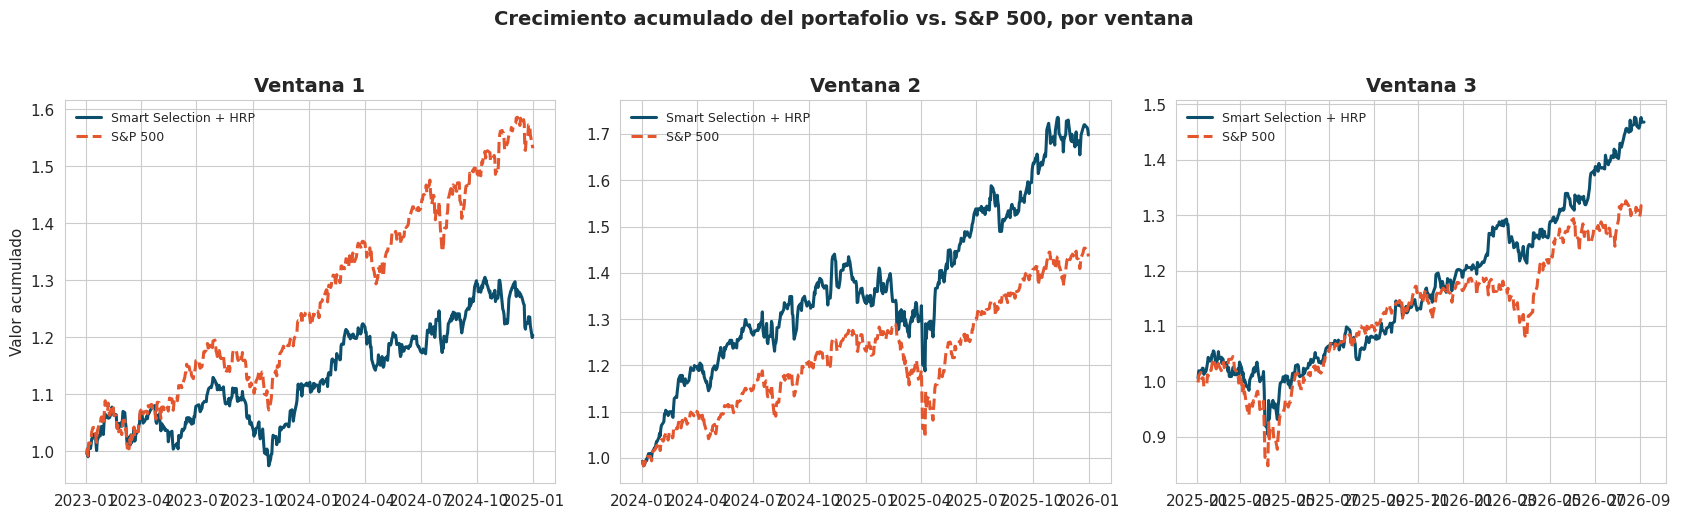

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=False)
for ax, v in zip(axes, [1, 2, 3]):
    for nombre, serie in cumulativos_ventana[v].items():
        color = NAVY if 'Smart' in nombre else ORANGE
        linestyle = '-' if 'Smart' in nombre else '--'
        ax.plot(serie, label=nombre, linewidth=2.2, color=color, linestyle=linestyle)
    ax.set_title(f'Ventana {v}')
    ax.legend(frameon=False, fontsize=9)
    ax.set_ylabel('Valor acumulado' if v == 1 else '')

plt.suptitle('Crecimiento acumulado del portafolio vs. S&P 500, por ventana', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

**Cómo leer estos resultados:** el promedio de las 3 ventanas no siempre refleja lo que pasó en cada una por separado. En la Ventana 1 (2023-2024), un rally de mercado muy concentrado en pocas empresas tecnológicas favoreció al S&P 500 (ponderado por capitalización) sobre cualquier estrategia diversificada. En las Ventanas 2 y 3, con un mercado menos concentrado, la estrategia superó al índice tanto en retorno como en las métricas ajustadas por riesgo.

## 11. Análisis crítico de las métricas de desempeño

Ninguna métrica de rendimiento es perfecta — sus limitaciones hay que declararlas, no solo calcular los números:

**Sharpe Ratio:** asume que los retornos siguen una distribución normal. En la práctica, las acciones tienen colas más pesadas (caídas extremas más frecuentes de lo que la normal predice), por lo que el Sharpe puede subestimar el riesgo real de una estrategia con asimetría negativa marcada.

**Índice de Treynor:** depende por completo de que el Beta esté bien estimado. Un Beta mal calculado (por ejemplo, cercano a cero) puede disparar el Treynor a valores poco significativos sin que el riesgo real haya cambiado. Además, solo es interpretable en portafolios ya razonablemente diversificados.

**Alfa de Jensen:** es sensible al benchmark elegido. Se usó el S&P 500 como referencia, pero un portafolio de 15 acciones tiene, por construcción, un perfil de riesgo distinto al del índice completo — parte del Alfa observado puede reflejar diferencias de exposición no capturadas por un único Beta de mercado, no necesariamente "habilidad" de la estrategia.

Por esta razón, el proyecto no se apoya en una sola métrica ni en una sola ventana de tiempo: se reportan las tres métricas, a través de tres periodos distintos, junto con su variabilidad.

## 12. Conclusiones

- **La curva de diversificación** confirma con datos reales que ~15 acciones ya capturan la gran mayoría del beneficio de diversificación disponible en el S&P 500.
- **Los pesos de HRP están inversamente relacionados con la volatilidad individual** de cada acción (Sección 8.1) — es la evidencia más directa de que el algoritmo reparte riesgo, no capital en partes iguales ni por retorno esperado.
- **Smart Selection mejora sobre el medoide puro** en Sharpe promedio, sin aumentar la volatilidad de forma relevante — una mejora simple de implementar y con beneficio medible.
- **La matriz de correlación y la red de diversificación** confirman que la selección final no quedó concentrada en un pequeño grupo de acciones altamente correlacionadas.
- **HRP con linkage `ward` y K=15** logró, en promedio de las 3 ventanas out-of-sample, un retorno y un Sharpe comparables (e incluso superiores en retorno) a los del S&P 500 — sin necesitar invertir la matriz de covarianza ni concentrar el riesgo por capitalización de mercado.
- **El resultado no fue uniforme entre ventanas:** en periodos de mercado muy concentrados en pocas empresas ganadoras, el índice ponderado por capitalización es difícil de superar con cualquier estrategia diversificada — un hallazgo honesto que forma parte de la conclusión, no una limitación a esconder.

**Posibles extensiones:**
- Probar más ventanas móviles (desplazamiento trimestral) para una validación más granular.
- Explorar otros criterios de Smart Selection (momentum reciente, menor volatilidad individual) y comparar su generalización fuera de muestra.
- Incorporar un tope máximo de peso por acción dentro de HRP, como control adicional de concentración.
